In [1]:
import sqlite3
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATA_DIR = Path("../data/raw")

df_p = pd.read_csv(DATA_DIR / "patient.csv")
df_t = pd.read_csv(DATA_DIR / "treatment.csv")
df_v = pd.read_csv(DATA_DIR / "vitalPeriodic.csv")
df_h = pd.read_csv(DATA_DIR / "hospital.csv")
df_d = pd.read_csv(DATA_DIR / "diagnosis.csv")

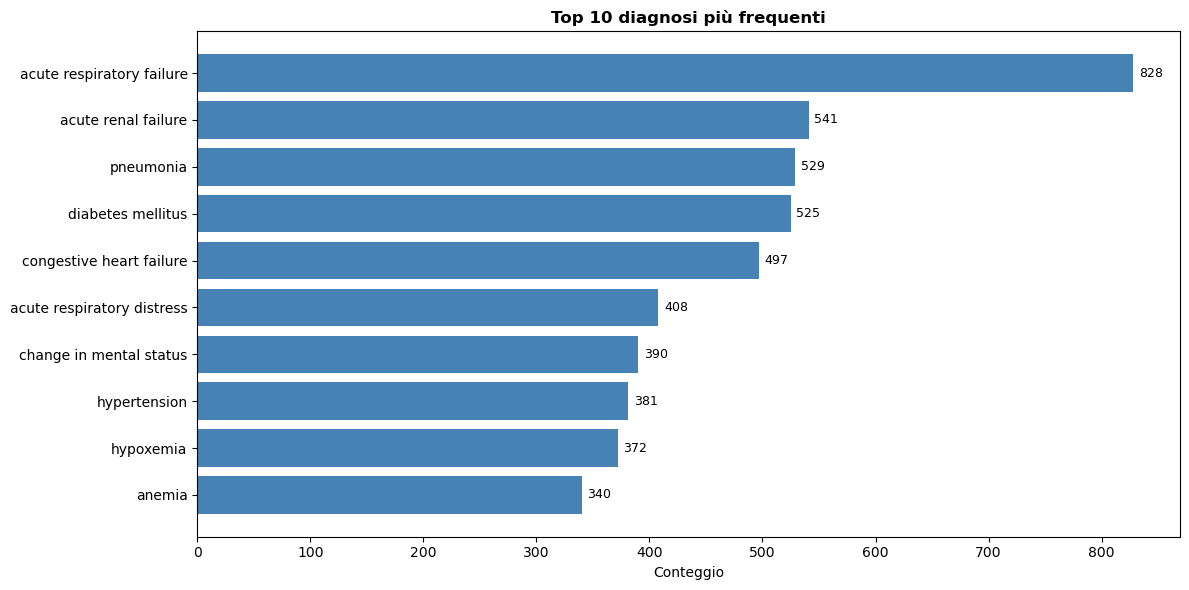

In [3]:
top10 = df_d["diagnosisstring"].value_counts().head(10)

# Abbrevia le etichette
labels = [d.split("|")[-1] for d in top10.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(labels, top10.values, color="steelblue")

for bar, val in zip(bars, top10.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)

ax.set_xlabel("Conteggio")
ax.set_title("Top 10 diagnosi più frequenti", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [4]:
pazienti_arf = df_d[df_d["diagnosisstring"] == 
                    "pulmonary|respiratory failure|acute respiratory failure"
                    ]["patientunitstayid"].unique()

print(f"Pazienti con ARF: {len(pazienti_arf)}")

# Join con trattamenti
trattamenti_arf = df_t[df_t["patientunitstayid"].isin(pazienti_arf)]

print(f"Trattamenti totali: {len(trattamenti_arf)}")
print("\nTop 20 trattamenti:")
print(trattamenti_arf["treatmentstring"].value_counts().head(20))

Pazienti con ARF: 226
Trattamenti totali: 10041

Top 20 trattamenti:
treatmentstring
pulmonary|ventilation and oxygenation|mechanical ventilation                                             476
pulmonary|radiologic procedures / bronchoscopy|chest x-ray                                               217
infectious diseases|medications|therapeutic antibacterials                                               142
pulmonary|consultations|Pulmonary/CCM consultation                                                       131
gastrointestinal|medications|stress ulcer prophylaxis|famotidine                                         122
cardiovascular|intravenous fluid|normal saline administration                                            118
pulmonary|ventilation and oxygenation|oxygen therapy (40% to 60%)                                        116
cardiovascular|vascular disorders|VTE prophylaxis|compression stockings                                  112
pulmonary|medications|bronchodilator       

In [5]:
pazienti_arf1 = df_d[df_d["diagnosisstring"] == 
                    "renal|disorder of kidney|acute renal failure"
                    ]["patientunitstayid"].unique()

print(f"Pazienti con arf1: {len(pazienti_arf1)}")

# Join con trattamenti
trattamenti_arf1 = df_t[df_t["patientunitstayid"].isin(pazienti_arf1)]

print(f"Trattamenti totali: {len(trattamenti_arf1)}")
print("\nTop 20 trattamenti:")
print(trattamenti_arf1["treatmentstring"].value_counts().head(20))

Pazienti con arf1: 186
Trattamenti totali: 5714

Top 20 trattamenti:
treatmentstring
pulmonary|ventilation and oxygenation|mechanical ventilation                                      247
pulmonary|radiologic procedures / bronchoscopy|chest x-ray                                        126
infectious diseases|medications|therapeutic antibacterials                                        100
endocrine|glucose metabolism|insulin                                                               99
pulmonary|medications|bronchodilator                                                               94
pulmonary|consultations|Pulmonary/CCM consultation                                                 85
gastrointestinal|medications|stress ulcer prophylaxis|pantoprazole                                 80
cardiovascular|vascular disorders|VTE prophylaxis|compression stockings                            73
cardiovascular|shock|vasopressors|norepinephrine > 0.1 micrograms/kg/min                           

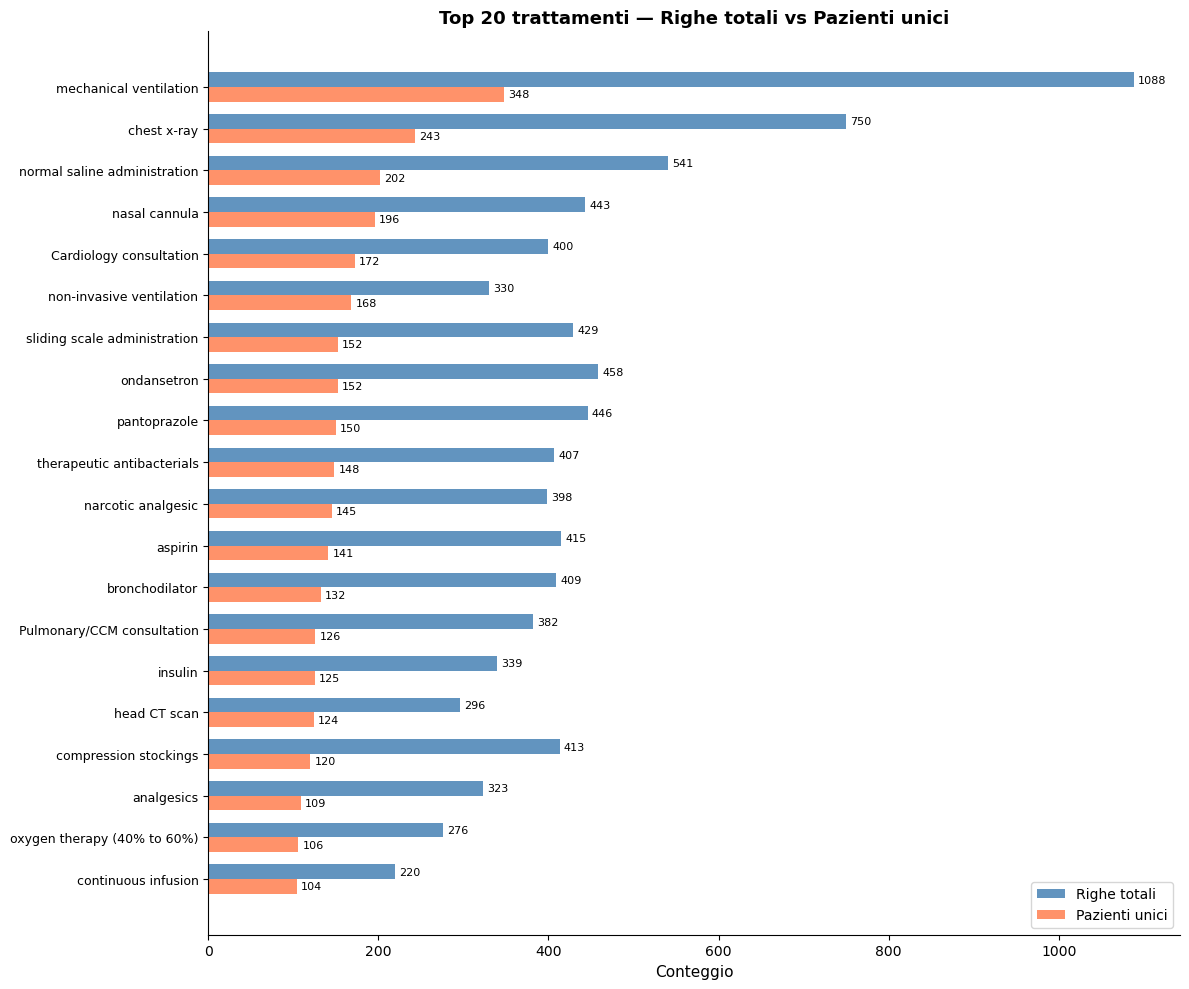

In [6]:
df_counts = pd.DataFrame({
    'righe_totali': df_t['treatmentstring'].value_counts(),
    'pazienti_unici': df_t.groupby('treatmentstring')['patientunitstayid'].nunique()
}).sort_values('pazienti_unici', ascending=True).tail(20)  # top 20

# Accorcia le label (prendi solo l'ultimo livello della gerarchia)
df_counts.index = df_counts.index.str.split('|').str[-1]

fig, ax = plt.subplots(figsize=(12, 10))

y = range(len(df_counts))
height = 0.35

bars1 = ax.barh(
    [i + height/2 for i in y],   #posizione delle barre
    df_counts['righe_totali'],
    height=height,
    label='Righe totali',
    color='steelblue',
    alpha=0.85
)
bars2 = ax.barh(
    [i - height/2 for i in y],
    df_counts['pazienti_unici'],
    height=height,
    label='Pazienti unici',
    color='coral',
    alpha=0.85
)

# Etichette valori
for bar in bars1:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,   #posizione testo centrato e a destra del wigdht
            f'{int(bar.get_width())}', va='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=8)

ax.set_yticks(list(y))
ax.set_yticklabels(df_counts.index, fontsize=9)
ax.set_xlabel('Conteggio', fontsize=11)
ax.set_title('Top 20 trattamenti — Righe totali vs Pazienti unici', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [7]:
# Calcola metriche per ospedale
hospital_stats = df_p.groupby('hospitalid').agg(
    stay_totali=('patientunitstayid', 'count'),
    pazienti_unici=('uniquepid', 'nunique'),
    tasso_mortalita=('hospitaldischargestatus', lambda x: (x == 'Expired').mean())
).round(3).reset_index()

# Unisci con le info ospedaliere
hospital_stats = hospital_stats.merge(
    df_h[['hospitalid', 'numbedscategory', 'teachingstatus', 'region']],
    on='hospitalid',
    how='left'
)

# Ordina per stay totali
hospital_stats = hospital_stats.sort_values('stay_totali', ascending=False)

print(f"Ospedali totali: {len(hospital_stats)}")
print(f"Tasso mortalità medio: {hospital_stats['tasso_mortalita'].mean():.3f}")
print()
print(hospital_stats.to_string(index=False))




Ospedali totali: 186
Tasso mortalità medio: 0.088

 hospitalid  stay_totali  pazienti_unici  tasso_mortalita numbedscategory teachingstatus    region
        146           40              10            0.050       250 - 499              f      West
        123           30              10            0.067       100 - 249              f     South
        171           25              10            0.120       100 - 249              f      West
        157           25              10            0.280       250 - 499              f      West
        167           24              10            0.000          >= 500              t      West
        155           24              10            0.083       100 - 249              f      West
        154           23              10            0.043       250 - 499              f      West
        310           22              10            0.091       100 - 249              f   Midwest
        243           22              10            0.045 

In [8]:
morti = df_p["unitdischargestatus"].value_counts()
print(morti)

# Percentuale
print(f"\nMorti: {(df_p['unitdischargestatus'] == 'Expired').sum()}")
print(f"Totale pazienti: {len(df_p)}")
print(f"Mortalità: {(df_p['unitdischargestatus'] == 'Expired').mean()*100:.1f}%")

unitdischargestatus
Alive      2392
Expired     126
Name: count, dtype: int64

Morti: 126
Totale pazienti: 2520
Mortalità: 5.0%


In [9]:
# Crea colonna ventilato
ventilati = df_t[df_t["treatmentstring"].str.contains(
    "mechanical ventilation", case=False, na=False
)]["patientunitstayid"].unique()

df_p["ventilato"] = df_p["patientunitstayid"].isin(ventilati).astype(int)

# Distribuzione morti per gruppo
dist = df_p.groupby("ventilato")["unitdischargestatus"].value_counts()
print(dist)

# Mortalità % per gruppo
print("\nMortalità per gruppo:")
print(df_p.groupby("ventilato")["unitdischargestatus"]
      .apply(lambda x: (x == "Expired").mean() * 100)
      .rename({0: "Non ventilati", 1: "Ventilati"}))

ventilato  unitdischargestatus
0          Alive                  2017
           Expired                  65
1          Alive                   375
           Expired                  61
Name: count, dtype: int64

Mortalità per gruppo:
ventilato
Non ventilati     3.119002
Ventilati        13.990826
Name: unitdischargestatus, dtype: float64


Età media: 63.3 anni
Età mediana: 66.0 anni
Missing età: 4


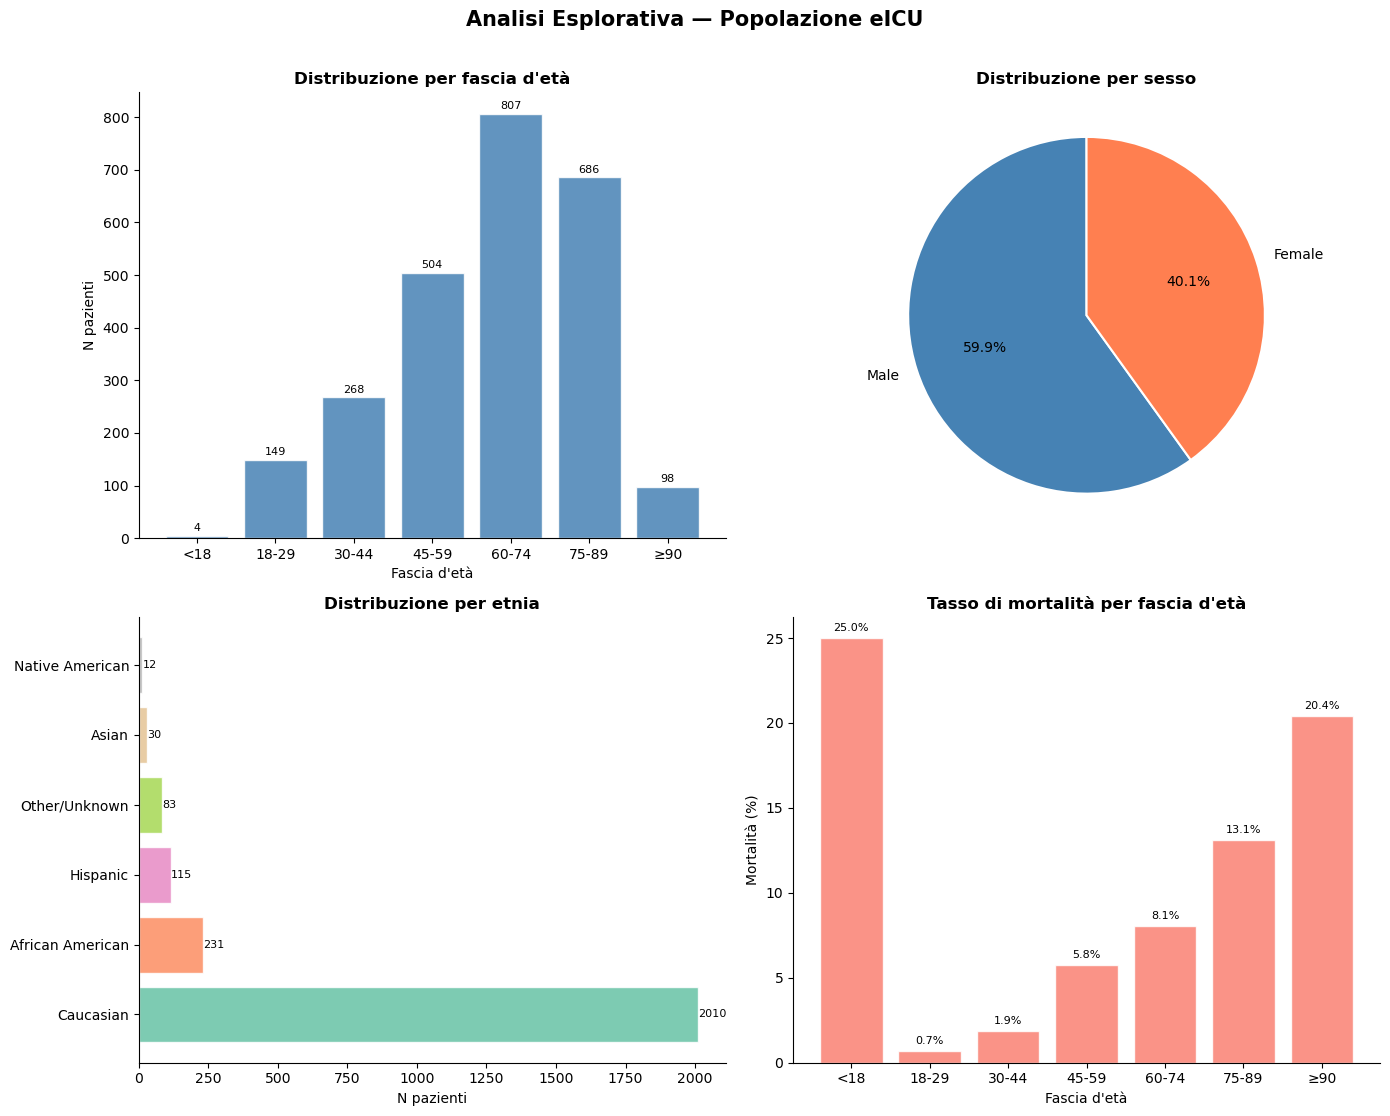


--- MORTALITÀ TOTALE ---
hospitaldischargestatus
Alive      2280
Expired     212
Name: count, dtype: int64

Tasso mortalità ospedaliera: 8.41%

--- SESSO ---
gender
Male      1508
Female    1008
Name: count, dtype: int64

--- ETNIA ---
ethnicity
Caucasian           2010
African American     231
Hispanic             115
Other/Unknown         83
Asian                 30
Native American       12
Name: count, dtype: int64


In [10]:

df_p = pd.read_csv('../data/raw/patient.csv')

# ============================================================
# PULIZIA PRELIMINARE
# ============================================================

# età: eICU usa ">89" come stringa per proteggere la privacy
df_p['age_clean'] = pd.to_numeric(df_p['age'], errors='coerce')
df_p.loc[df_p['age'] == '> 89', 'age_clean'] = 90  # convenzione comune

print(f"Età media: {df_p['age_clean'].mean():.1f} anni")
print(f"Età mediana: {df_p['age_clean'].median():.1f} anni")
print(f"Missing età: {df_p['age_clean'].isna().sum()}")

# ============================================================
# FIGURA — 4 grafici in una
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Analisi Esplorativa — Popolazione eICU', 
             fontsize=15, fontweight='bold', y=1.01)

# --- GRAFICO 1 — Distribuzione età ---
ax1 = axes[0, 0]
bins = [0, 18, 30, 45, 60, 75, 90, 120]
labels = ['<18', '18-29', '30-44', '45-59', '60-74', '75-89', '≥90']
df_p['fascia_eta'] = pd.cut(df_p['age_clean'], bins=bins, labels=labels, right=False)
counts = df_p['fascia_eta'].value_counts().sort_index()
bars = ax1.bar(counts.index, counts.values, color='steelblue', alpha=0.85, edgecolor='white')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
ax1.set_title('Distribuzione per fascia d\'età', fontweight='bold')
ax1.set_xlabel('Fascia d\'età')
ax1.set_ylabel('N pazienti')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- GRAFICO 2 — Torta sesso ---
ax2 = axes[0, 1]
sesso = df_p['gender'].value_counts()
colori = ['steelblue', 'coral', 'lightgray']
wedges, texts, autotexts = ax2.pie(
    sesso.values,
    labels=sesso.index,
    autopct='%1.1f%%',
    colors=colori[:len(sesso)],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for text in autotexts:
    text.set_fontsize(10)
ax2.set_title('Distribuzione per sesso', fontweight='bold')

# --- GRAFICO 3 — Etnia ---
ax3 = axes[1, 0]
etnia = df_p['ethnicity'].value_counts()
colors_etnia = plt.cm.Set2(np.linspace(0, 1, len(etnia)))
bars3 = ax3.barh(etnia.index, etnia.values, color=colors_etnia, alpha=0.85, edgecolor='white')
for bar in bars3:
    ax3.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())), va='center', fontsize=8)
ax3.set_title('Distribuzione per etnia', fontweight='bold')
ax3.set_xlabel('N pazienti')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# --- GRAFICO 4 — Mortalità per fascia età ---
ax4 = axes[1, 1]
df_p['deceduto'] = (df_p['hospitaldischargestatus'] == 'Expired').astype(int)
mortalita_eta = df_p.groupby('fascia_eta', observed=True)['deceduto'].mean() * 100
bars4 = ax4.bar(mortalita_eta.index, mortalita_eta.values, color='salmon', alpha=0.85, edgecolor='white')
for bar in bars4:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
ax4.set_title('Tasso di mortalità per fascia d\'età', fontweight='bold')
ax4.set_xlabel('Fascia d\'età')
ax4.set_ylabel('Mortalità (%)')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('esplorazione_popolazione.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# STATISTICHE TESTUALI
# ============================================================
print("\n--- MORTALITÀ TOTALE ---")
print(df_p['hospitaldischargestatus'].value_counts())
print(f"\nTasso mortalità ospedaliera: {df_p['deceduto'].mean()*100:.2f}%")

print("\n--- SESSO ---")
print(df_p['gender'].value_counts())

print("\n--- ETNIA ---")
print(df_p['ethnicity'].value_counts())

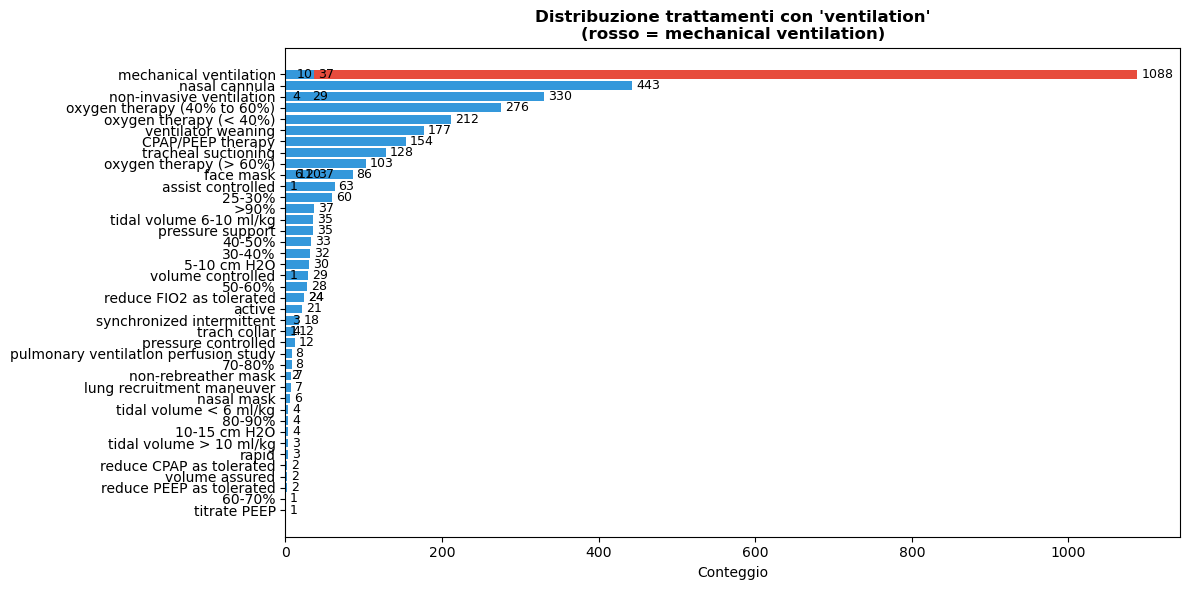

In [11]:
#confrontre la distribuzione fra i vari trattamenti "ventilation"

# Filtra tutti i trattamenti che contengono "ventilation"
ventilation_treatments = df_t[df_t["treatmentstring"].str.contains("ventilation", case=False, na=False)]

# Conta le occorrenze
counts = ventilation_treatments["treatmentstring"].value_counts()

# Separa il principale dagli altri
main = "pulmonary|ventilation and oxygenation|mechanical ventilation"
main_count = counts.get(main, 0)
others = counts.drop(main, errors="ignore")

# Combina per il plot
plot_data = pd.concat([pd.Series({main: main_count}), others])

# Abbrevia le etichette per leggibilità
labels = [t.split("|")[-1] if "|" in t else t for t in plot_data.index]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#e74c3c"] + ["#3498db"] * len(others)
bars = ax.barh(labels, plot_data.values, color=colors)

# Aggiungi i valori sulle barre
for bar, val in zip(bars, plot_data.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)

ax.set_xlabel("Conteggio")
ax.set_title("Distribuzione trattamenti con 'ventilation'\n(rosso = mechanical ventilation)", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()



In [12]:
mask = df_t["treatmentstring"].str.contains("ventilation", case=False, na=False)
total = mask.sum()
print(f"Trattamenti con ventilazione: {total}")

#unici per pazienti
total_pazienti = df_t[mask]["patientunitstayid"].nunique()
print(f"Pazienti con ventilazione: {total_pazienti}")



Trattamenti con ventilazione: 3718
Pazienti con ventilazione: 826


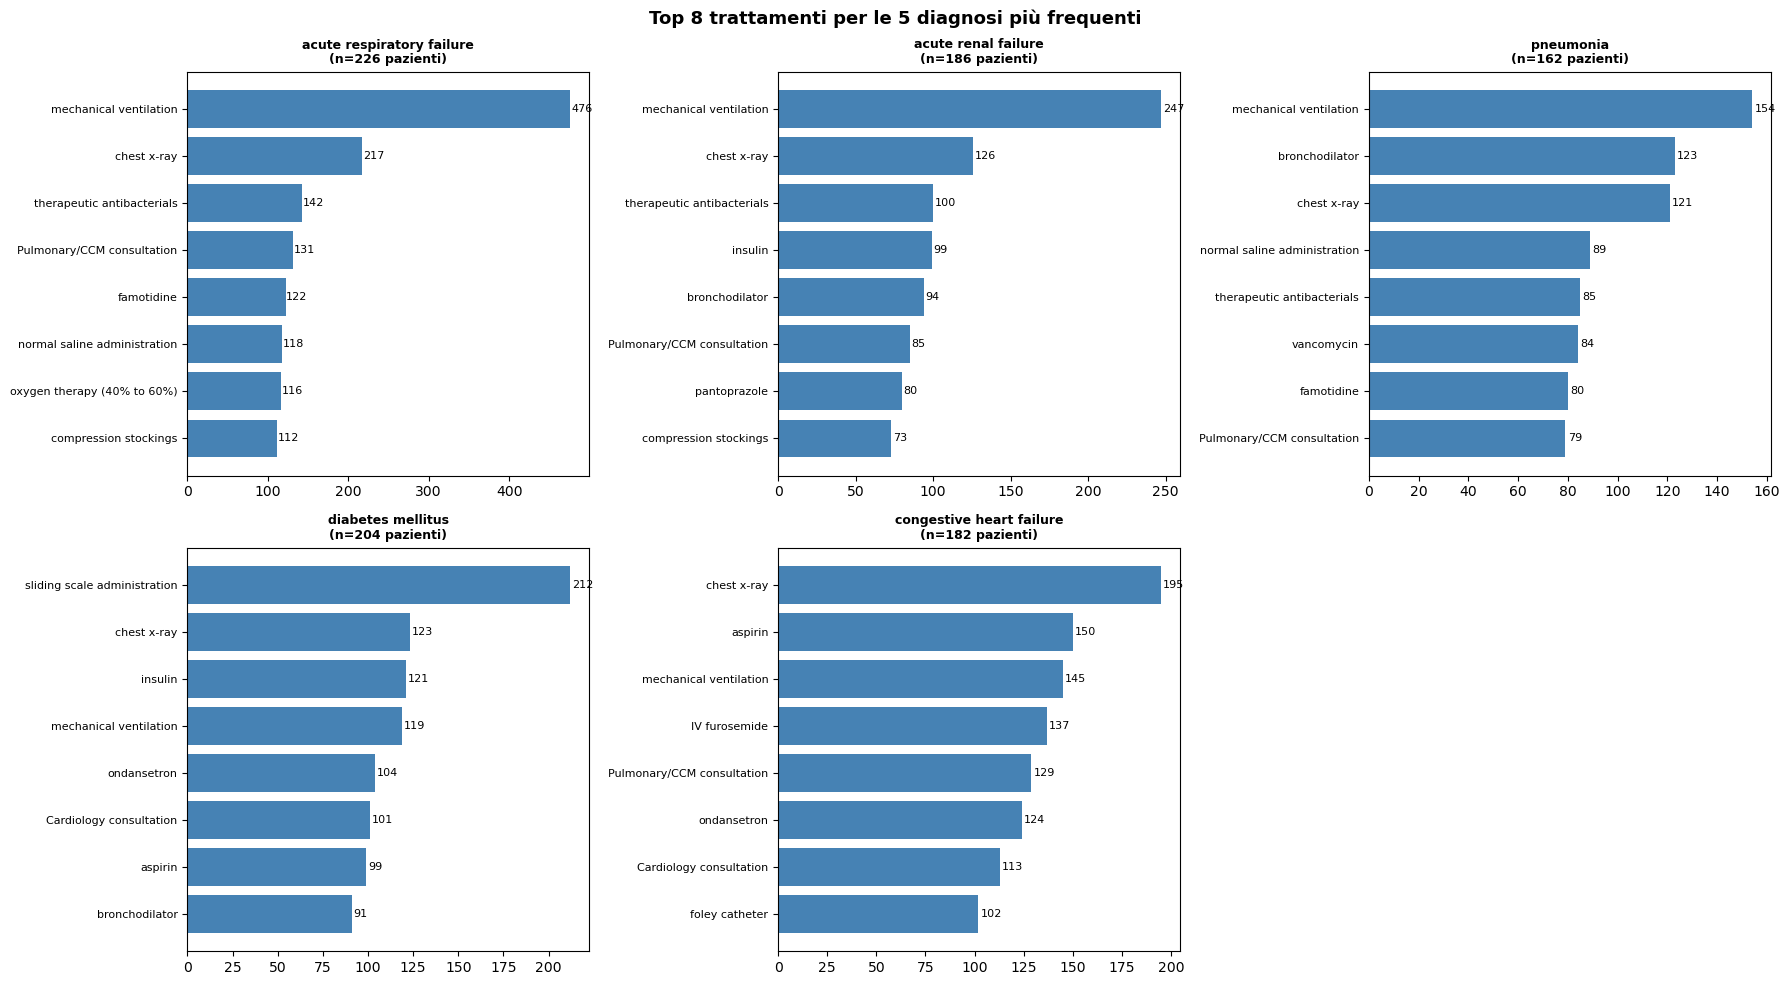

In [13]:
import matplotlib.pyplot as plt

top5_diagnosi = df_d["diagnosisstring"].value_counts().head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, diagnosi in enumerate(top5_diagnosi):
    pazienti = df_d[df_d["diagnosisstring"] == diagnosi]["patientunitstayid"].unique()
    trattamenti = df_t[df_t["patientunitstayid"].isin(pazienti)]["treatmentstring"].value_counts().head(8)
    
    # Abbrevia etichette
    labels = [t.split("|")[-1] for t in trattamenti.index]
    label_diagnosi = diagnosi.split("|")[-1]
    
    ax = axes[i]
    bars = ax.barh(labels, trattamenti.values, color="steelblue")
    
    for bar, val in zip(bars, trattamenti.values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(val), va="center", fontsize=8)
    
    ax.set_title(f"{label_diagnosi}\n(n={len(pazienti)} pazienti)", 
                 fontweight="bold", fontsize=9)
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=8)

# Nascondi subplot vuoto
axes[-1].set_visible(False)

fig.suptitle("Top 8 trattamenti per le 5 diagnosi più frequenti", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()